In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#### **1.Load the text page photo in grayscale**

In [12]:
img_raw = cv2.imread('img.jpg', cv2.IMREAD_GRAYSCALE)

h, w = img_raw.shape[:2]
img_text = cv2.resize(img_raw, (800, int(h * (800 / w))))



#### **2. Apply Otsu's Thresholding (Automatic global binarization) and Apply Morphological Closing**

In [13]:
_, otsu_thresh = cv2.threshold(img_text, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

text_white_bg_black = cv2.bitwise_not(otsu_thresh)
kernel_size = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
closed_inv = cv2.morphologyEx(otsu_thresh, cv2.MORPH_CLOSE, kernel)
closed_img = cv2.bitwise_not(closed_inv)

#### **3.Extract a Before/After Crop of One Word**

In [17]:
ymin, ymax = int(img_text.shape[0] * 0.12), int(img_text.shape[0] * 0.22)
xmin, xmax = int(img_text.shape[1] * 0.20), int(img_text.shape[1] * 0.75)

word_crop_before = otsu_thresh[ymin:ymax, xmin:xmax]
word_crop_after  = closed_img[ymin:ymax, xmin:xmax]


#### **5. Visualization Loop**


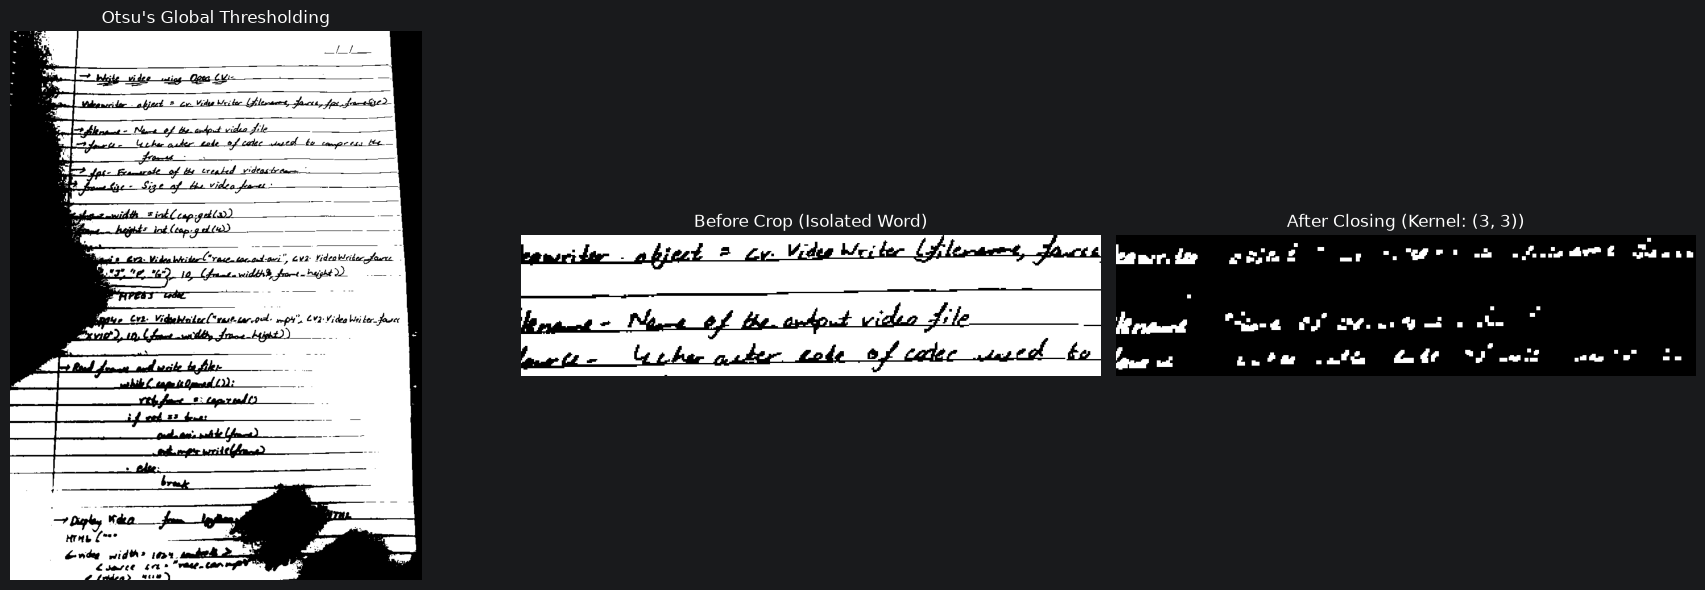

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(otsu_thresh, cmap='gray')
axes[0].set_title("Otsu's Global Thresholding")
axes[0].axis('off')

axes[1].imshow(word_crop_before, cmap='gray')
axes[1].set_title("Before Crop (Isolated Word)")
axes[1].axis('off')

axes[2].imshow(word_crop_after, cmap='gray')
axes[2].set_title(f"After Closing (Kernel: {kernel_size})")
axes[2].axis('off')

plt.tight_layout()
plt.show()